#  SECTION 1: IMPORT LIBRARIES

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift,OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score , calinski_harabasz_score
from sklearn.decomposition import PCA
import pickle
from google.colab import files

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


# SECTION 2: LOADING DATASET & TAKING A 10K SAMPLE

In [ ]:
import os
from google.colab import files

if not os.path.exists('customerData_500k.csv'):
    print(" File not found — please upload it now...")
    uploaded = files.upload()
else:
    print("✅ File already exists — skipping upload.")

df_full = pd.read_csv('customerData_500k.csv')
print(f"✅ Full dataset loaded: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# Take a reproducible random sample of 10,000 rows
df = df_full.sample(n=10000, random_state=42).reset_index(drop=True)
print(f"✅ 10,000-row sample extracted.")
print(df.head())


 File not found — please upload it now...


Saving customerData_500k.csv to customerData_500k.csv
✅ Full dataset loaded: 500,000 rows × 17 columns
✅ 10,000-row sample extracted.
   Age   AnnualIncome  NumberOfPurchases  TimeSpentOnWebsite  \
0   40   60252.640397                  7           19.361407   
1   23   97121.879854                 11           13.392196   
2   66   37094.887262                  5           41.336203   
3   46   88327.651602                  9           24.640941   
4   47  121295.869872                 20           54.446919   

   CustomerTenureYears  LastPurchaseDaysAgo  Gender ProductCategory  \
0             2.432603                  149  Female       Furniture   
1             0.254283                   18  Female         Fashion   
2             3.497200                   20  Female         Kitchen   
3             0.229415                  134  Female         Fashion   
4             4.067941                  111    Male         Fashion   

  PreferredDevice Region ReferralSource CustomerSegmen

#  SECTION 3: RENAME COLUMNS TO MATCH THE PROJECT FEATURES

In [ ]:
df = df.rename(columns={
    'Age':                 'age',
    'AnnualIncome':        'income',
    'NumberOfPurchases':   'purchase_frequency',
    'TimeSpentOnWebsite':  'time_on_website',
    'CustomerTenureYears': 'tenure_years',
    'LastPurchaseDaysAgo': 'days_since_purchase',
    'LoyaltyProgram':      'loyalty_program',
    'DiscountsAvailed':    'discounts_availed',
    'SessionCount':        'session_count',
    'CustomerSatisfaction':'customer_satisfaction',
    'Region':              'region',
})

print("\n✅ Columns renamed. Current columns:")
print(df.columns.tolist())


✅ Columns renamed. Current columns:
['age', 'income', 'purchase_frequency', 'time_on_website', 'tenure_years', 'days_since_purchase', 'Gender', 'ProductCategory', 'PreferredDevice', 'region', 'ReferralSource', 'CustomerSegment', 'loyalty_program', 'discounts_availed', 'session_count', 'customer_satisfaction', 'PurchaseStatus']


#  SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
print("\n========== DATA INFO ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())


========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    10000 non-null  int64  
 1   income                 10000 non-null  float64
 2   purchase_frequency     10000 non-null  int64  
 3   time_on_website        10000 non-null  float64
 4   tenure_years           10000 non-null  float64
 5   days_since_purchase    10000 non-null  int64  
 6   Gender                 10000 non-null  object 
 7   ProductCategory        10000 non-null  object 
 8   PreferredDevice        10000 non-null  object 
 9   region                 10000 non-null  object 
 10  ReferralSource         10000 non-null  object 
 11  CustomerSegment        10000 non-null  object 
 12  loyalty_program        10000 non-null  int64  
 13  discounts_availed      10000 non-null  int64  
 14  session_count         

# SECTION 5: DATA CLEANING

In [ ]:
df = df.drop_duplicates()
print("\n✅ Duplicates removed.")

df = df.dropna()
print("✅ Missing values removed.")

print(f"✅ Clean sample shape: {df.shape}")



✅ Duplicates removed.
✅ Missing values removed.
✅ Clean sample shape: (10000, 17)


# SECTION 6: FEATURE ENGINEERING

In [ ]:
# --- spending_score ---
# Combines income level, purchase volume, and discount usage
# Scale each component 0-1, then blend into a 0-100 score
df['spending_score'] = (
    (df['income']              / df['income'].max())              * 0.5 +
    (df['purchase_frequency']  / df['purchase_frequency'].max())  * 0.3 +
    (df['discounts_availed']   / df['discounts_availed'].max())   * 0.2
) * 100
print("\n✅ spending_score created.")

# --- loyalty_score ---
# Combines loyalty programme membership, customer satisfaction, and tenure
df['loyalty_score'] = (
    (df['loyalty_program']        / df['loyalty_program'].max())        * 0.4 +
    (df['customer_satisfaction']  / df['customer_satisfaction'].max())  * 0.4 +
    (df['tenure_years']           / df['tenure_years'].max())           * 0.2
) * 100
print("✅ loyalty_score created.")

# --- online_activity ---
# Combines session count, time spent on website, and purchase frequency
df['online_activity'] = (
    (df['session_count']       / df['session_count'].max())       * 0.4 +
    (df['time_on_website']     / df['time_on_website'].max())     * 0.4 +
    (df['purchase_frequency']  / df['purchase_frequency'].max())  * 0.2
) * 100
print("✅ online_activity created.")


✅ spending_score created.
✅ loyalty_score created.
✅ online_activity created.


# SECTION 7: DROP UNNECESSARY COLUMNS

In [ ]:
# List of columns to be removed based on the feature selection phase
cols_to_drop = [
    'Gender',
    'ProductCategory',
    'PreferredDevice',
    'ReferralSource',
    'CustomerSegment',
    'PurchaseStatus',
    'days_since_purchase'
]

# Drop columns; errors='ignore' prevents KeyError if columns are already missing
df = df.drop(columns=cols_to_drop, errors='ignore')

print("\n✅ Unnecessary columns dropped (or were already absent).")
print("Remaining columns:", df.columns.tolist())


✅ Unnecessary columns dropped (or were already absent).
Remaining columns: ['age', 'income', 'purchase_frequency', 'time_on_website', 'tenure_years', 'region', 'loyalty_program', 'discounts_availed', 'session_count', 'customer_satisfaction', 'spending_score', 'loyalty_score', 'online_activity']


#  SECTION 8: ENCODING — REGION COLUMN

In [ ]:
# Check if 'region' exists before attempting encoding
if 'region' in df.columns:
    df['region'] = df['region'].str.strip().str.lower()

    expected_regions = ['north', 'south', 'east', 'west']

    # Perform One-Hot Encoding
    df = pd.get_dummies(df, columns=['region'], drop_first=False)

    # Ensure all 4 region columns exist even if one was missing from the sample
    for region in expected_regions:
        col = f'region_{region}'
        if col not in df.columns:
            df[col] = 0
            print(f"Warning: '{col}' was missing from sample - added as 0.")

    print("\nRegion encoding done.")
    print("Region columns:", [col for col in df.columns if 'region_' in col])
else:
    print("Info: 'region' column not found. It may have already been encoded or dropped.")


Region encoding done.
Region columns: ['region_east', 'region_north', 'region_south', 'region_west']


# SECTION 9: COLUMN NAME CLEANUP

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print("\n✅ Column names cleaned.")
print(df.columns.tolist())


✅ Column names cleaned.
['age', 'income', 'purchase_frequency', 'time_on_website', 'tenure_years', 'loyalty_program', 'discounts_availed', 'session_count', 'customer_satisfaction', 'spending_score', 'loyalty_score', 'online_activity', 'region_east', 'region_north', 'region_south', 'region_west']


# SECTION 10: FEATURE SELECTION & SCALING


In [ ]:
features = [
    'age',
    'income',
    'spending_score',
    'purchase_frequency',
    'loyalty_score',
    'online_activity',
    'region_north',
    'region_south',
    'region_east',
    'region_west'
]

# Safety check — confirm all features exist
missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"\n⚠️ These features are missing from df: {missing_features}")
else:
    print("\n✅ All features confirmed present.")

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Scaling completed.")


✅ All features confirmed present.
✅ Scaling completed.


# SECTION 11: FINAL DATASET CHECK

In [ ]:
print("\n========== FINAL DATASET CHECK ==========")
print("Missing values:  ", df.isnull().sum().sum())
print("Duplicate rows:  ", df.duplicated().sum())
print("Dataset shape:   ", df.shape)
print("Features used:   ", features)

print("\n========== CLEANED DATASET PREVIEW ==========")
print(df[features].head())

print("\n==================================================")
print("✅ DATASET IS CLEANED AND READY FOR CLUSTERING")
print("==================================================")


========== FINAL DATASET CHECK ==========
Missing values:   0
Duplicate rows:   0
Dataset shape:    (10000, 16)
Features used:    ['age', 'income', 'spending_score', 'purchase_frequency', 'loyalty_score', 'online_activity', 'region_north', 'region_south', 'region_east', 'region_west']

========== CLEANED DATASET PREVIEW ==========
   age         income  spending_score  purchase_frequency  loyalty_score  \
0   40   60252.640397       23.406769                   7      43.213219   
1   23   97121.879854       41.389572                  11      32.335882   
2   66   37094.887262       27.239004                   5      28.619443   
3   46   88327.651602       34.799246                   9      32.303033   
4   47  121295.869872       62.210445                  20      77.373334   

   online_activity  region_north  region_south  region_east  region_west  
0        32.752137         False         False         True        False  
1        29.386085          True         False        False

# SECTION 12: FIND OPTIMAL K — ELBOW METHOD

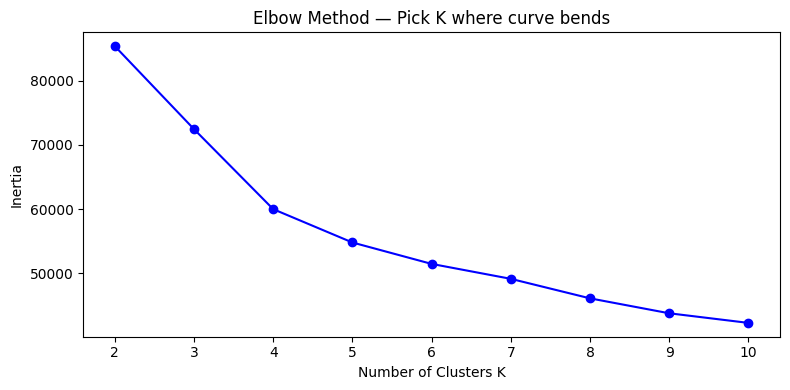


✅ Optimal K set to: 4


In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Pick K where curve bends')
plt.tight_layout()
plt.show()

# *** LOOK AT THE CHART AND SET YOUR K BELOW ***
OPTIMAL_K = 4

print(f"\n✅ Optimal K set to: {OPTIMAL_K}")

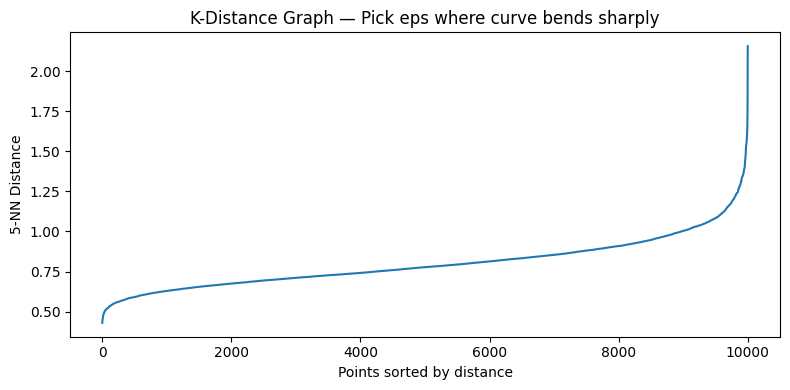

In [ ]:
# DBSCAN TUNING — K-DISTANCE GRAPH
from sklearn.neighbors import NearestNeighbors

k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('5-NN Distance')
plt.title('K-Distance Graph — Pick eps where curve bends sharply')
plt.tight_layout()
plt.show()

# SECTION 13: RUNNING  ALL 5 CLUSTERING ALGORITHMS

In [ ]:

# 1. KMeans
km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
labels_kmeans = km.fit_predict(X_scaled)
print("✅ KMeans done.")

# 2. DBSCAN
db = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = db.fit_predict(X_scaled)
print("✅ DBSCAN done.")

# DBSCAN cluster investigation
print("DBSCAN label distribution:")
unique, counts = np.unique(labels_dbscan, return_counts=True)
for label, count in zip(unique, counts):
    if label == -1:
        print(f"  Noise points: {count}")
    else:
        print(f"  Cluster {label}: {count} customers")

# 3. Agglomerative
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K)
labels_agg = agg.fit_predict(X_scaled)
print("✅ Agglomerative done.")

# 4. Gaussian Mixture
gmm = GaussianMixture(n_components=OPTIMAL_K, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
print("✅ Gaussian Mixture done.")

# 5. MeanShift
ms = MeanShift()
labels_ms = ms.fit_predict(X_scaled)
print("✅ MeanShift done.")

 # 6. OPTICS — tuned for this dataset
opt = OPTICS(
    min_samples=10,
    xi=0.01,
    min_cluster_size=0.05  # lowered from 0.1 to 0.05 (only needs 5% = 500 customers)
)
labels_optics = opt.fit_predict(X_scaled)
print("✅ OPTICS done.")
print(f"   Clusters found: {len(set(labels_optics)) - (1 if -1 in labels_optics else 0)}")
print(f"   Noise points:   {list(labels_optics).count(-1)}")

all_results = {
    'KMeans':          labels_kmeans,
    'DBSCAN':          labels_dbscan,
    'Agglomerative':   labels_agg,
    'GaussianMixture': labels_gmm,
    'MeanShift':       labels_ms,
    'OPTICS':          labels_optics,   # ← add this
}

✅ KMeans done.
✅ DBSCAN done.
DBSCAN label distribution:
  Noise points: 3
  Cluster 0: 1967 customers
  Cluster 1: 2440 customers
  Cluster 2: 3607 customers
  Cluster 3: 1983 customers
✅ Agglomerative done.
✅ Gaussian Mixture done.
✅ MeanShift done.
✅ OPTICS done.
   Clusters found: 4
   Noise points:   0


# SECTION 14: EVALUATE ALL ALGORITHMS

In [ ]:
print(f"\n{'Algorithm':<20} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20} {'Clusters':>10}")
print("-" * 82)

for name, labels in all_results.items():
    unique_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if unique_clusters < 2:
        print(f"{name:<20} {'N/A':>12} {'N/A':>16} {'N/A':>20} {unique_clusters:>10}")
        continue
    sil   = silhouette_score(X_scaled, labels)
    db_sc = davies_bouldin_score(X_scaled, labels)
    cal   = calinski_harabasz_score(X_scaled, labels)
    print(f"{name:<20} {sil:>12.4f} {db_sc:>16.4f} {cal:>20.2f} {unique_clusters:>10}")



Algorithm              Silhouette   Davies-Bouldin    Calinski-Harabasz   Clusters
----------------------------------------------------------------------------------
KMeans                     0.2895           1.4911              2223.30          4
DBSCAN                     0.2868           1.9908              1667.93          4
Agglomerative              0.2895           1.4911              2223.30          4
GaussianMixture            0.2895           1.4911              2223.30          4
MeanShift                     N/A              N/A                  N/A          1
OPTICS                     0.2895           1.4911              2223.30          4


# SECTION 15: VISUALIZE CLUSTERS (PCA 2D)


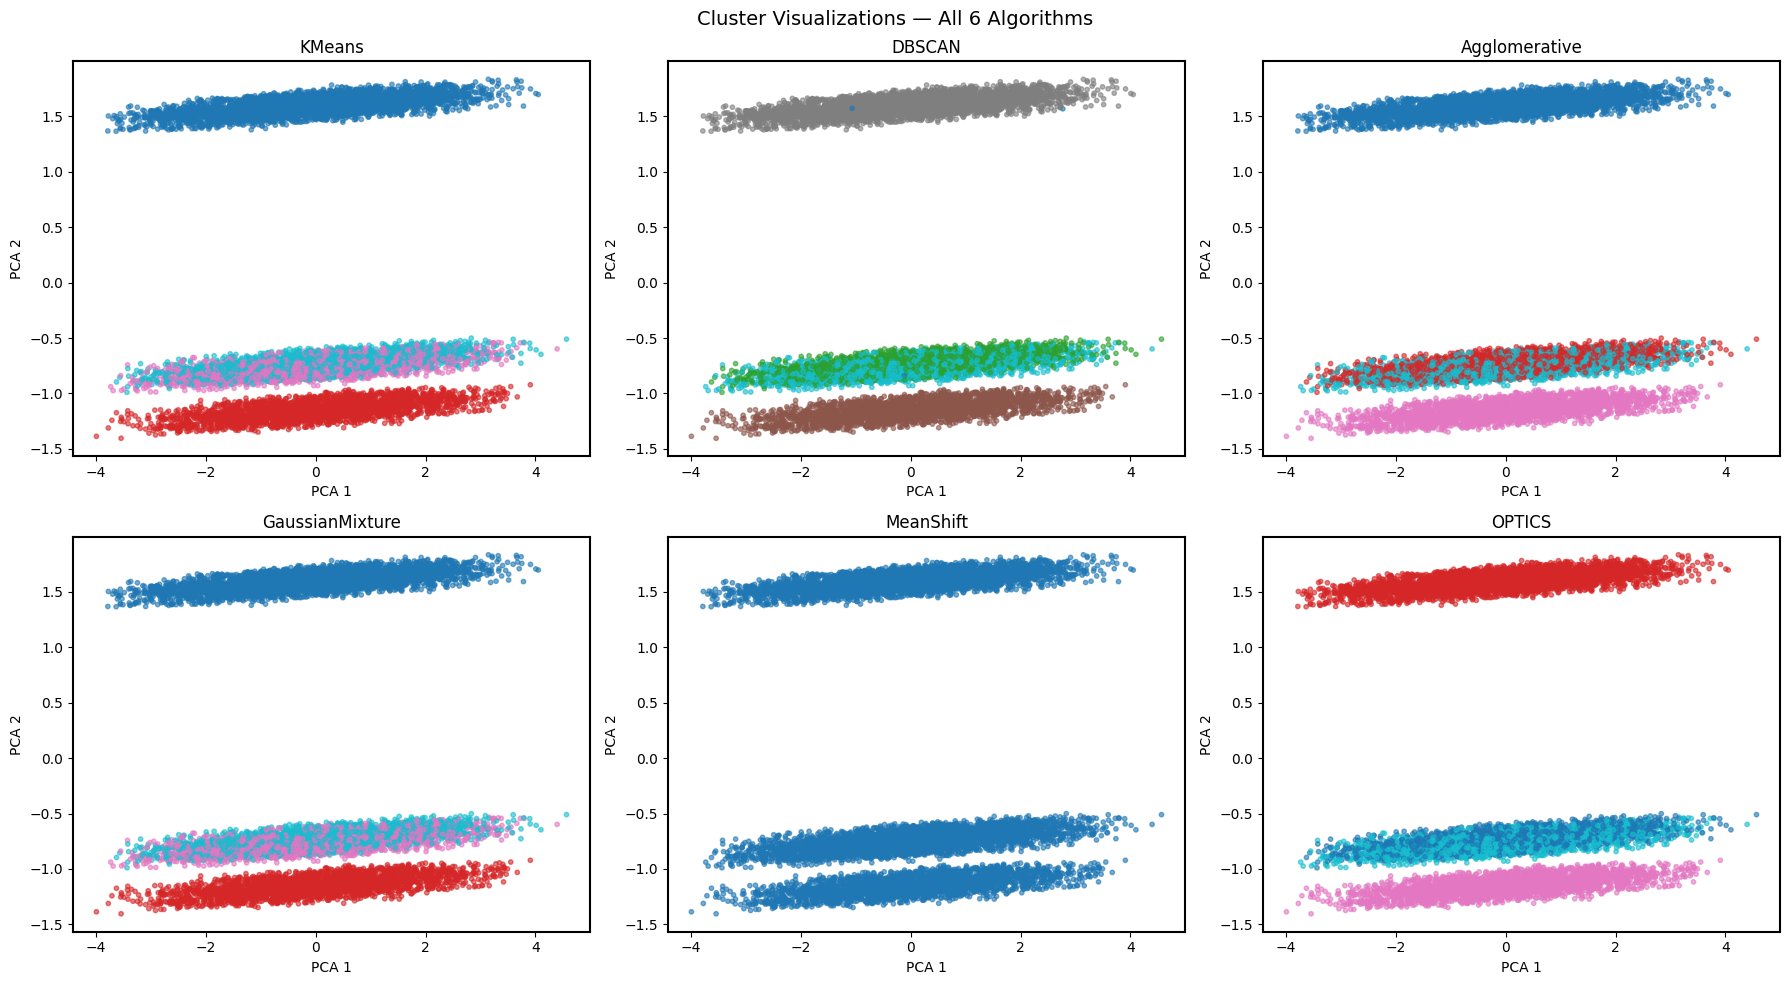

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, labels) in enumerate(all_results.items()):
    axes[i].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=10, alpha=0.6)
    axes[i].set_title(name)
    axes[i].set_xlabel('PCA 1')
    axes[i].set_ylabel('PCA 2')
    for spine in axes[i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

plt.suptitle('Cluster Visualizations — All 6 Algorithms', fontsize=14)
plt.tight_layout()
plt.show()

#  SECTION 16: CLUSTER PROFILING (BEST MODEL)


========== CLUSTER PROFILES ==========
           age    income  spending_score  purchase_frequency  loyalty_score  \
Cluster                                                                       
0        43.77  84475.14           41.04               11.38          48.95   
1        44.31  85726.13           41.28               11.42          48.42   
2        44.54  85791.06           41.34               11.35          48.19   
3        44.39  84940.94           41.54               11.66          48.61   

         online_activity  
Cluster                   
0                  33.26  
1                  33.40  
2                  33.30  
3                  34.13  


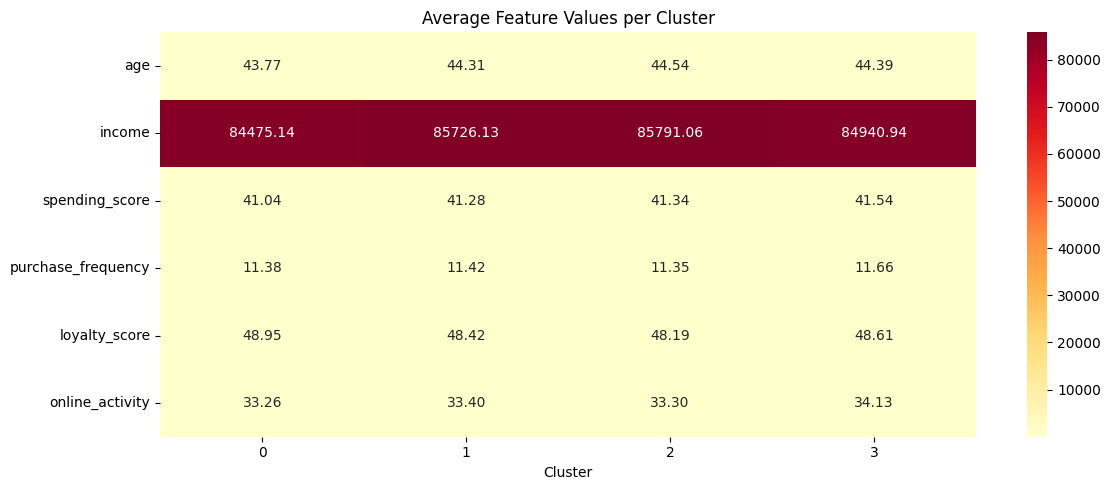

In [ ]:
df['Cluster'] = labels_kmeans

profile = df.groupby('Cluster')[[
    'age',
    'income',
    'spending_score',
    'purchase_frequency',
    'loyalty_score',
    'online_activity'
]].mean().round(2)

print("\n========== CLUSTER PROFILES ==========")
print(profile)

plt.figure(figsize=(12, 5))
sns.heatmap(profile.T, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Average Feature Values per Cluster")
plt.tight_layout()
plt.show()

# Section 16.5: Label Clusters


========== SEGMENT DISTRIBUTION ==========
Segment
Loyal Mid Spenders        3609
High Income Shoppers      2440
High Income Regulars      1983
Active Frequent Buyers    1968
Name: count, dtype: int64


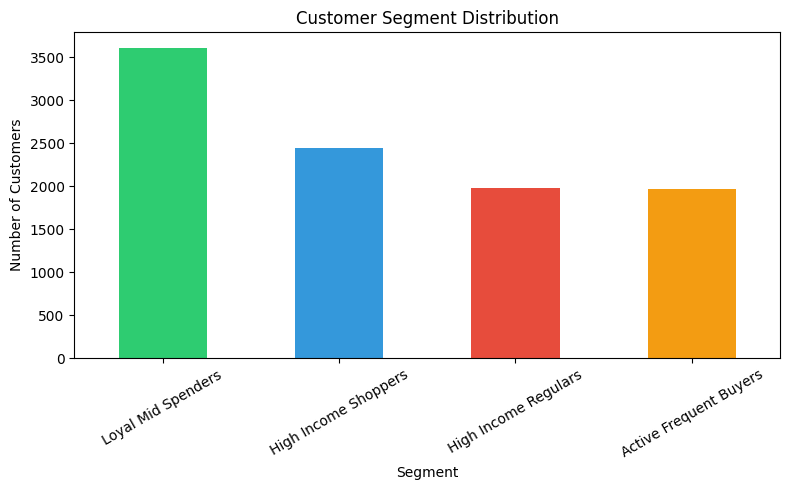

In [ ]:
cluster_labels = {
    0: 'Loyal Mid Spenders',      # highest loyalty_score (48.95)
    1: 'High Income Shoppers',    # highest income (85,726)
    2: 'High Income Regulars',    # highest income (85,791)
    3: 'Active Frequent Buyers'   # highest purchase_frequency (11.66) & online_activity (34.13)
}

df['Segment'] = df['Cluster'].map(cluster_labels)

print("\n========== SEGMENT DISTRIBUTION ==========")
print(df['Segment'].value_counts())

plt.figure(figsize=(8, 5))
df['Segment'].value_counts().plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c','#f39c12'])
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# SECTION 17: SAVE MODELS WITH PICKLE

In [ ]:
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(km, f)
print("✅ KMeans model saved.")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved.")

import json
with open('feature_names.json', 'w') as f:
    json.dump(features, f)
print("✅ Feature names saved.")


✅ KMeans model saved.
✅ Scaler saved.
✅ Feature names saved.


# SECTION 18: DATASET VISUALIZATION

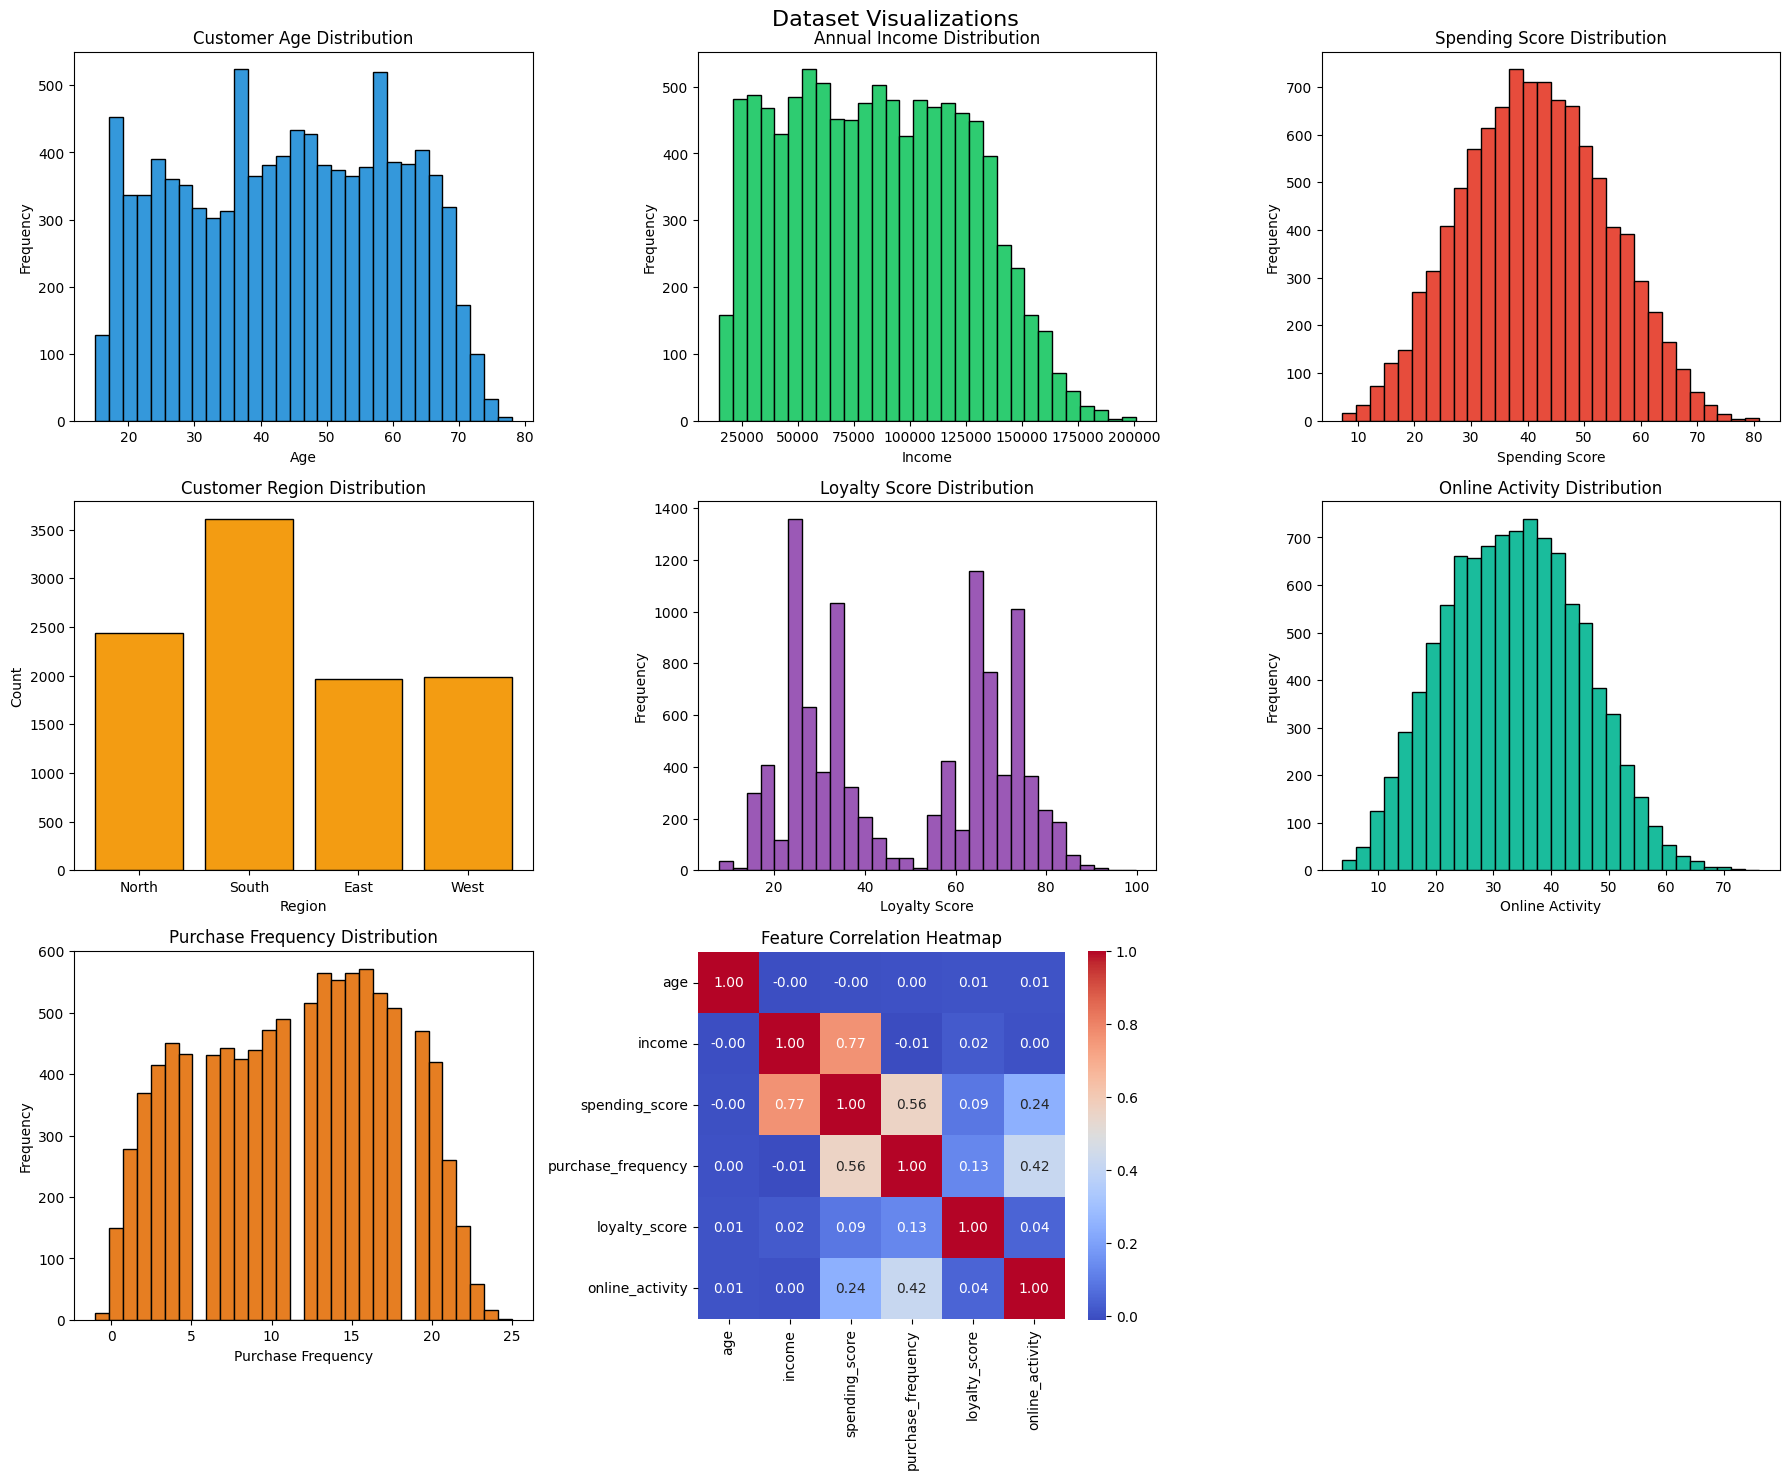

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# 1. Age Distribution
axes[0].hist(df['age'], bins=30, color='#3498db', edgecolor='black')
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# 2. Income Distribution
axes[1].hist(df['income'], bins=30, color='#2ecc71', edgecolor='black')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Frequency')

# 3. Spending Score Distribution
axes[2].hist(df['spending_score'], bins=30, color='#e74c3c', edgecolor='black')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Frequency')

# 4. Region Distribution
region_cols = ['region_north', 'region_south', 'region_east', 'region_west']
region_counts = df[region_cols].sum()
region_counts.index = ['North', 'South', 'East', 'West']
axes[3].bar(region_counts.index, region_counts.values, color='#f39c12', edgecolor='black')
axes[3].set_title('Customer Region Distribution')
axes[3].set_xlabel('Region')
axes[3].set_ylabel('Count')

# 5. Loyalty Score Distribution
axes[4].hist(df['loyalty_score'], bins=30, color='#9b59b6', edgecolor='black')
axes[4].set_title('Loyalty Score Distribution')
axes[4].set_xlabel('Loyalty Score')
axes[4].set_ylabel('Frequency')

# 6. Online Activity Distribution
axes[5].hist(df['online_activity'], bins=30, color='#1abc9c', edgecolor='black')
axes[5].set_title('Online Activity Distribution')
axes[5].set_xlabel('Online Activity')
axes[5].set_ylabel('Frequency')

# 7. Purchase Frequency Distribution
axes[6].hist(df['purchase_frequency'], bins=30, color='#e67e22', edgecolor='black')
axes[6].set_title('Purchase Frequency Distribution')
axes[6].set_xlabel('Purchase Frequency')
axes[6].set_ylabel('Frequency')

# 8. Feature Correlation Heatmap
axes[7].remove()
ax_heatmap = fig.add_subplot(3, 3, 8)
corr_features = ['age', 'income', 'spending_score', 'purchase_frequency',
                 'loyalty_score', 'online_activity']
corr_matrix = df[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax_heatmap, square=True)
ax_heatmap.set_title('Feature Correlation Heatmap')

# Hide last empty subplots
axes[8].axis('off')

plt.suptitle('Dataset Visualizations', fontsize=16)
plt.tight_layout()
plt.show()


#  SECTION 19 : EVALUATION METRICS BAR CHART

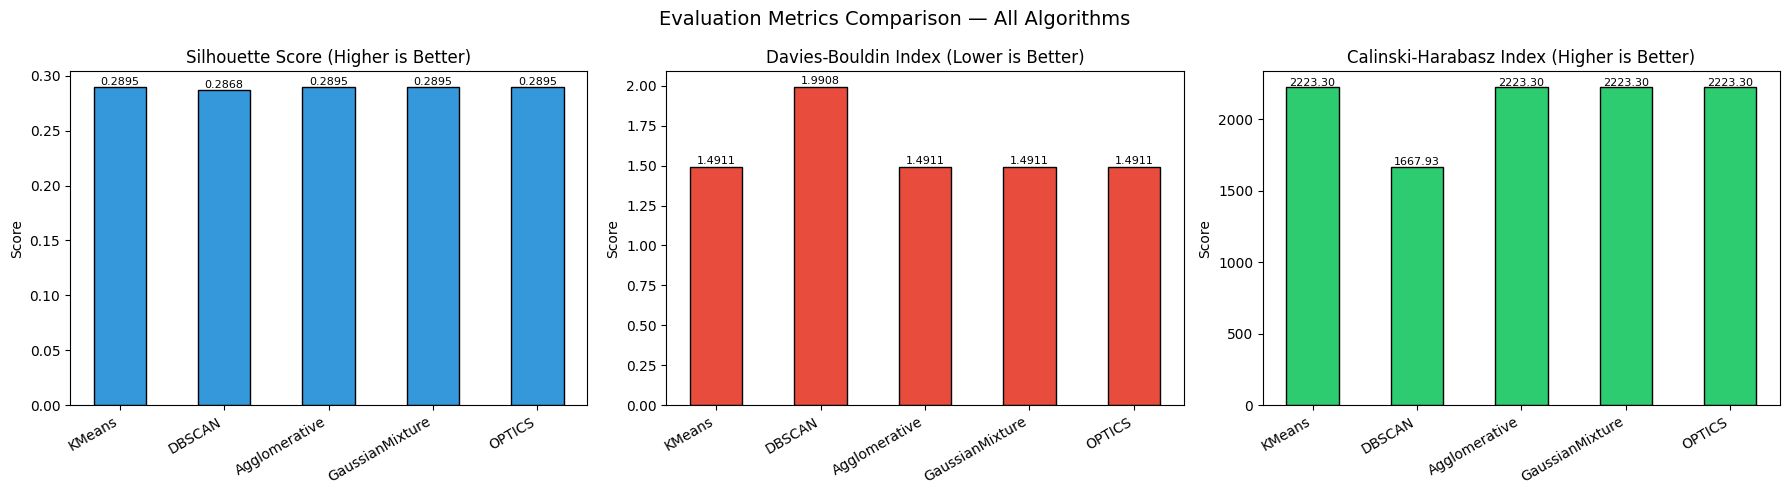

✅ Metrics visualization saved as fifth_metrics.png


In [ ]:
algorithms = ['KMeans', 'DBSCAN', 'Agglomerative', 'GaussianMixture', 'OPTICS']

silhouette_scores   = [0.2895, 0.2868, 0.2895, 0.2895, 0.2895]
davies_bouldin      = [1.4911, 1.9908, 1.4911, 1.4911, 1.4911]
calinski_harabasz   = [2223.30, 1667.93, 2223.30, 2223.30, 2223.30]

x = np.arange(len(algorithms))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
axes[0].bar(x, silhouette_scores, width=0.5, color='#3498db', edgecolor='black')
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(algorithms, rotation=30, ha='right')
axes[0].set_ylabel('Score')
for i, v in enumerate(silhouette_scores):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=8)

# Davies-Bouldin
axes[1].bar(x, davies_bouldin, width=0.5, color='#e74c3c', edgecolor='black')
axes[1].set_title('Davies-Bouldin Index (Lower is Better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(algorithms, rotation=30, ha='right')
axes[1].set_ylabel('Score')
for i, v in enumerate(davies_bouldin):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=8)

# Calinski-Harabasz
axes[2].bar(x, calinski_harabasz, width=0.5, color='#2ecc71', edgecolor='black')
axes[2].set_title('Calinski-Harabasz Index (Higher is Better)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(algorithms, rotation=30, ha='right')
axes[2].set_ylabel('Score')
for i, v in enumerate(calinski_harabasz):
    axes[2].text(i, v + 10, f'{v:.2f}', ha='center', fontsize=8)

plt.suptitle('Evaluation Metrics Comparison — All Algorithms', fontsize=14)
plt.tight_layout()
plt.savefig('fifth_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics visualization saved as fifth_metrics.png")